# Experience Gap Evaluation Methods
Comparative framework for modeling the Experience Gap (`Delta_E`) feature inside the CV-screening pipeline.

**Evaluation Metric:** Spearman's Rank Correlation. This measures how perfectly our mathematical models match the sorting order a real human recruiter would choose.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from scipy.stats import spearmanr
from IPython.display import display

# ---------------------------------------------------------
# Environment Setup (Colab vs Local)
# ---------------------------------------------------------
RUNNING_IN_COLAB = 'google.colab' in str(get_ipython())

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/project/cv screening'
    os.makedirs(PROJECT_DIR, exist_ok=True)
    sys.path.append(PROJECT_DIR)
else:
    PROJECT_DIR = '.'

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
IMAGE_DIR = os.path.join(PROJECT_DIR, 'images')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

Mounted at /content/drive


### 1. Mathematical Adjustment Models
Here we define the three distinct ways to handle the gap between a candidate's experience and the job's requirements.

In [2]:
def linear_penalty(delta_e, slope=0.05):
    """Method A: Standard Linear Penalty. Deducts a fixed amount per year of missing experience."""
    return np.minimum(delta_e * slope, 0)

def quadratic_penalty(delta_e, alpha=0.04, beta=0.01):
    """Method B: Human Recruiter Logic. Harsh penalty for missing years, slight reward for extra years."""
    return np.where(delta_e < 0, -alpha * (delta_e ** 2), beta * delta_e)

def sigmoid_bayesian_score(delta_e, match_score, k=0.35):
    """Method C: Bayesian Probability. Uses a smooth decay curve to represent confidence in the candidate."""
    likelihood = 1.0 / (1.0 + np.exp(-k * delta_e))

    eps = 1e-6
    prior = np.clip(match_score, eps, 1 - eps)
    likelihood = np.clip(likelihood, eps, 1 - eps)

    numerator = likelihood * prior
    denominator = numerator + (1 - likelihood) * (1 - prior)
    return numerator / denominator

### 2. Pipeline Application & Evaluation
Apply the formulas to the dataset and calculate which method best mimics human judgment.

In [3]:
def apply_methods(df):
    """Calculates the Delta E and applies all three adjustment methods to the dataset."""
    df = df.copy()

    if 'Delta_E' not in df.columns:
        df['Delta_E'] = df['Exp_cand'] - df['Exp_req']

    df['Score_Linear'] = np.clip(df['Match_Score'] + linear_penalty(df['Delta_E']), 0, 1)
    df['Score_Quadratic'] = np.clip(df['Match_Score'] + quadratic_penalty(df['Delta_E']), 0, 1)
    df['Score_Sigmoid'] = sigmoid_bayesian_score(df['Delta_E'], df['Match_Score'])

    return df

def evaluate_rankings(df):
    """Compares each method against a Human Target Score using Spearman Correlation."""
    correlations = {
        'Linear': spearmanr(df['Human_Target_Score'], df['Score_Linear'])[0],
        'Quadratic': spearmanr(df['Human_Target_Score'], df['Score_Quadratic'])[0],
        'Sigmoid': spearmanr(df['Human_Target_Score'], df['Score_Sigmoid'])[0]
    }

    results_df = pd.DataFrame(list(correlations.items()), columns=['Method', 'Spearman_Score'])
    return results_df.sort_values(by='Spearman_Score', ascending=False).reset_index(drop=True)

### 3. Visual Comparison
Plot the behavior of all three methods to visually confirm how aggressively they penalize candidates.

In [4]:
def plot_method_comparison(baseline_score=0.75):
    """Generates a line graph comparing the score drops across a 10-year experience swing."""
    delta_e = np.linspace(-5, 5, 200)
    base_scores = np.full_like(delta_e, baseline_score)

    y_linear = np.clip(base_scores + linear_penalty(delta_e), 0, 1)
    y_quad = np.clip(base_scores + quadratic_penalty(delta_e), 0, 1)
    y_sigmoid = sigmoid_bayesian_score(delta_e, base_scores)

    plt.figure(figsize=(10, 6))
    plt.plot(delta_e, y_linear, label="Linear (Baseline)", linestyle="--", color="#4A90E2")
    plt.plot(delta_e, y_quad, label="Quadratic (Deployed)", linewidth=2.5, color="#F5A623")
    plt.plot(delta_e, y_sigmoid, label="Sigmoid-Bayesian (Proposed)", linewidth=2.5, color="#50E3C2")

    plt.axvline(0, color="#9B9B9B", linestyle=":", label="Exact Match (0 Gap)")
    plt.axhline(baseline_score, color="#9B9B9B", linestyle=":", alpha=0.6)

    plt.xlabel("Experience Mismatch (Years)", fontweight='bold')
    plt.ylabel("Final Adjusted Match Score", fontweight='bold')
    plt.title(f"Experience Gap Penalty Curves (Baseline Score = {baseline_score})", fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    save_path = os.path.join(IMAGE_DIR, 'experience_gap_comparison.png')
    plt.savefig(save_path, dpi=300)
    plt.show()

### 4. Execute Demonstration on Real Dataset
Run the visualization and apply the models to the actual `ml_ready_dataset.csv`.

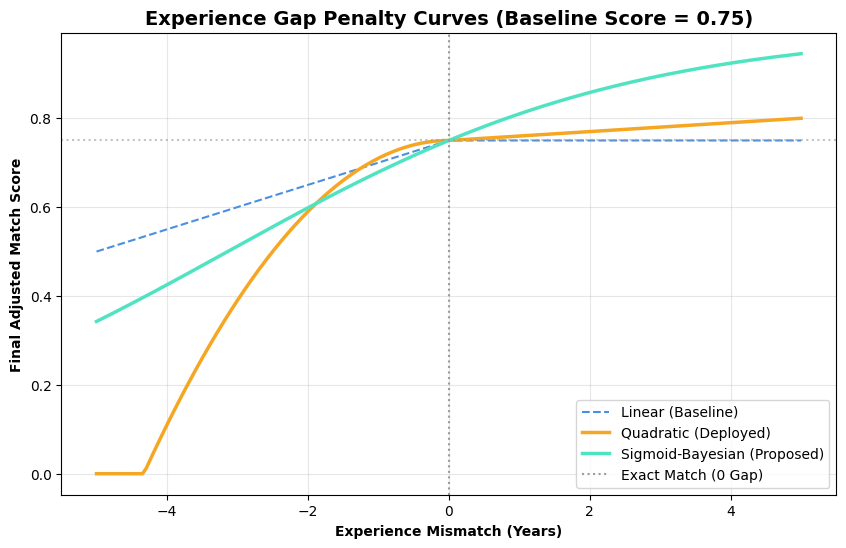

,Exp_cand,Exp_req,Delta_E,Match_Score,Human_Target_Score,Score_Linear,Score_Quadratic,Score_Sigmoid
0,6.7,1.0,5.7,0.654,0.850,0.654,0.711,0.933
1,6.8,5.0,1.8,0.776,0.750,0.776,0.794,0.866
2,8.1,3.0,5.1,0.741,0.417,0.741,0.792,0.945
3,13.8,1.0,12.8,0.623,0.760,0.623,0.751,0.993
4,18.5,4.0,14.5,0.693,0.650,0.693,0.838,0.997
5,19.5,0.0,19.5,0.683,0.850,0.683,0.878,0.999
6,0.7,4.0,-3.3,0.786,0.650,0.621,0.351,0.537
7,20.5,4.0,16.5,0.797,0.650,0.797,0.962,0.999
8,7.1,2.0,5.1,0.699,0.550,0.699,0.750,0.933
9,7.5,1.0,6.5,0.720,0.383,0.720,0.785,0.962


,Method,Spearman_Score
0,Linear,0.312933
1,Quadratic,0.257794
2,Sigmoid,0.175684


In [5]:
# 1. Display the visual comparison
plot_method_comparison()

# 2. Load the real dataset utilizing the dynamic DATA_DIR
csv_path = os.path.join(DATA_DIR, 'ml_ready_dataset.csv')
df_real = pd.read_csv(csv_path)

# Rename columns to match the framework's expected nomenclature
df_real = df_real.rename(columns={
    'Effective_Experience_Years': 'Exp_cand',
    'Cosine_Semantic': 'Match_Score',
    'matched_score': 'Human_Target_Score'
})

# Reverse-engineer the required experience (Exp_req)
df_real['Exp_req'] = np.where(
    df_real['Experience_Penalty'] >= 0,
    df_real['Exp_cand'] - df_real['Experience_Penalty'],
    df_real['Exp_cand'] + np.sqrt(np.abs(df_real['Experience_Penalty']))
)

# 3. Process the dataset
processed_data = apply_methods(df_real)

columns_to_view = ['Exp_cand', 'Exp_req', 'Delta_E', 'Match_Score', 'Human_Target_Score',
                   'Score_Linear', 'Score_Quadratic', 'Score_Sigmoid']

display(processed_data[columns_to_view].head(10).round(3))
display(evaluate_rankings(processed_data))

### 5. Exploratory Data Analysis (EDA): Experience Gap Distribution
Generate a histogram of $\Delta E$ across the entire dataset to observe the saturation impact.

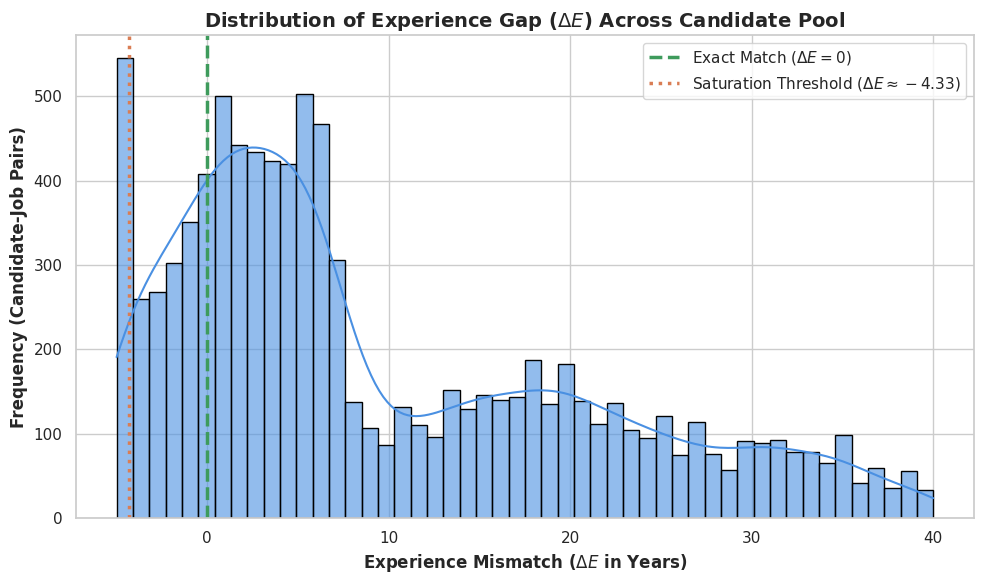

In [7]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the histogram with KDE overlay
sns.histplot(data=processed_data['Delta_E'].dropna(), bins=50, kde=True,
             color='#4A90E2', edgecolor='black', alpha=0.6)

# Vertical reference lines (using raw strings r'' to prevent LaTeX escape errors)
plt.axvline(x=0, color='#3E9B5C', linestyle='--', linewidth=2.5,
            label=r'Exact Match ($\Delta E = 0$)')
plt.axvline(x=-4.33, color='#D97D54', linestyle=':', linewidth=2.5,
            label=r'Saturation Threshold ($\Delta E \approx -4.33$)')

# Apply academic formatting and labels (using raw strings r'')
plt.title(r'Distribution of Experience Gap ($\Delta E$) Across Candidate Pool', fontsize=14, fontweight='bold')
plt.xlabel(r'Experience Mismatch ($\Delta E$ in Years)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (Candidate-Job Pairs)', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=11, frameon=True)

# Save the output directly to the dynamic IMAGE_DIR
plt.tight_layout()
save_path = os.path.join(IMAGE_DIR, 'delta_e_distribution.png')
plt.savefig(save_path, dpi=300)
plt.show()